In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt


In [2]:
all_students = pd.read_csv('students.csv') 
all_students.head()

,courses,createdAt,email,entryYear,gradeLevel,id,name,phone,schoolId,totalScore,type,updatedAt
0,"[""CRS960285"", ""CRS262471"", ""CRS622832"", ""CRS69...",2025-05-19T20:15:13.607124,timothy861@student.revoducate.edu,2023,9,406896307,Timothy Chambers,815-646-0462x575,SCH920609,64.4,student,2025-05-19T20:15:13.637618
1,"[""CRS960285"", ""CRS262471"", ""CRS622832"", ""CRS69...",2025-05-19T20:15:13.608122,andres673@student.revoducate.edu,2020,12,189073804,Andres Cook,001-791-495-1117x770,SCH920609,75.1,student,2025-05-19T20:15:13.638618
2,"[""CRS960285"", ""CRS262471"", ""CRS622832"", ""CRS69...",2025-05-19T20:15:13.607124,christopher150@student.revoducate.edu,2023,9,268953945,Christopher Velazquez,489-222-7378,SCH920609,80.3,student,2025-05-19T20:15:13.639790
3,"[""CRS960285"", ""CRS262471"", ""CRS698669"", ""CRS45...",2025-05-19T20:15:13.608122,cynthia164@student.revoducate.edu,2021,11,540321422,Cynthia Tyler,001-879-788-4080x9376,SCH920609,98.8,student,2025-05-19T20:15:13.641565
4,"[""CRS960285"", ""CRS262471"", ""CRS622832"", ""CRS69...",2025-05-19T20:15:13.607124,jennifer169@student.revoducate.edu,2023,9,772372806,Jennifer Jordan,001-778-522-6441x3951,SCH920609,59.9,student,2025-05-19T20:15:13.642566


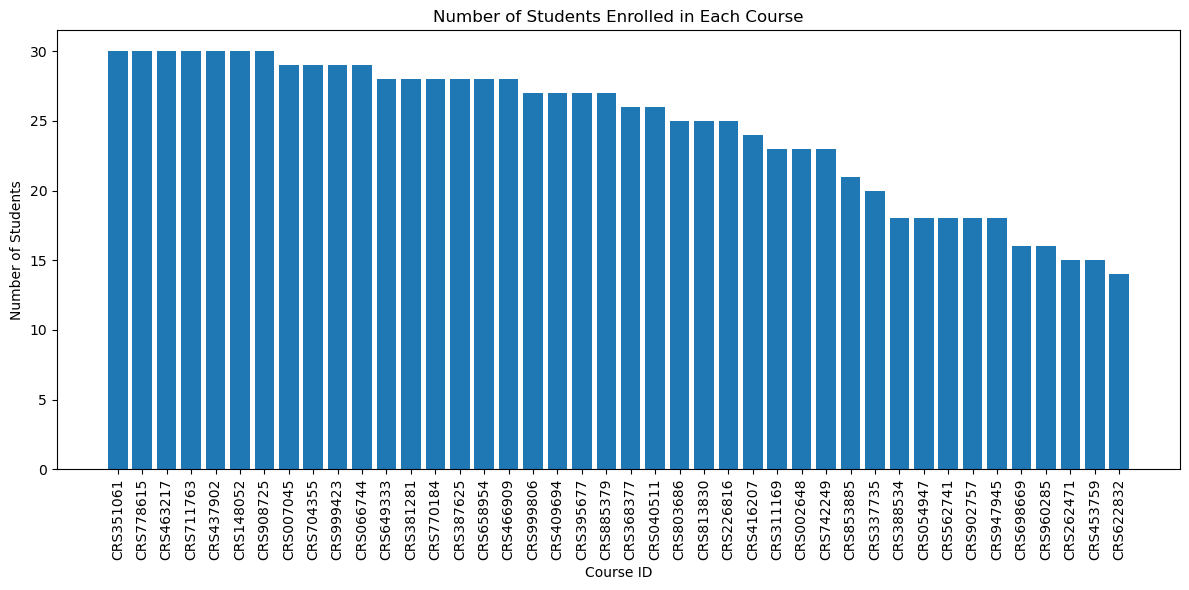

       Course  Student Count
0   CRS351061             30
1   CRS778615             30
2   CRS463217             30
3   CRS711763             30
4   CRS437902             30
5   CRS148052             30
6   CRS908725             30
7   CRS007045             29
8   CRS704355             29
9   CRS999423             29
10  CRS066744             29
11  CRS649333             28
12  CRS381281             28
13  CRS770184             28
14  CRS387625             28
15  CRS658954             28
16  CRS466909             28
17  CRS999806             27
18  CRS409694             27
19  CRS395677             27
20  CRS885379             27
21  CRS368377             26
22  CRS040511             26
23  CRS803686             25
24  CRS813830             25
25  CRS226816             25
26  CRS416207             24
27  CRS311169             23
28  CRS002648             23
29  CRS742249             23
30  CRS853885             21
31  CRS337735             20
32  CRS388534             18
33  CRS054947 

In [3]:

# Assuming all_students is your existing DataFrame
# Convert the string representation of courses to actual lists
all_students['parsed_courses'] = all_students['courses'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Explode the DataFrame so each student-course pair gets its own row
student_courses = all_students.explode('parsed_courses')

# Count the number of students per course
course_counts = student_courses['parsed_courses'].value_counts().reset_index()
course_counts.columns = ['Course', 'Student Count']

# Create the plot
plt.figure(figsize=(12, 6))
plt.bar(course_counts['Course'], course_counts['Student Count'])
plt.xlabel('Course ID')
plt.ylabel('Number of Students')
plt.title('Number of Students Enrolled in Each Course')
plt.xticks(rotation=90)
plt.tight_layout()

# Display the plot
plt.show()

# Print the data for reference
print(course_counts)

In [4]:
all_courses = set()

# Parse the 'courses' column for each student
for course_str in all_students['courses']:
    try:
        # Parse the string representation of a list
        courses = ast.literal_eval(course_str)
        # Add each course to the set
        for course in courses:
            all_courses.add(course)
    except:
        # Skip rows with parsing issues
        continue

# Count the number of different courses
num_different_courses = len(all_courses)
print(f"Number of different courses: {num_different_courses}")
print("List of courses:", sorted(all_courses))

Number of different courses: 42
List of courses: ['CRS002648', 'CRS007045', 'CRS040511', 'CRS054947', 'CRS066744', 'CRS148052', 'CRS226816', 'CRS262471', 'CRS311169', 'CRS337735', 'CRS351061', 'CRS368377', 'CRS381281', 'CRS387625', 'CRS388534', 'CRS395677', 'CRS409694', 'CRS416207', 'CRS437902', 'CRS453759', 'CRS463217', 'CRS466909', 'CRS562741', 'CRS622832', 'CRS649333', 'CRS658954', 'CRS698669', 'CRS704355', 'CRS711763', 'CRS742249', 'CRS770184', 'CRS778615', 'CRS803686', 'CRS813830', 'CRS853885', 'CRS885379', 'CRS902757', 'CRS908725', 'CRS947945', 'CRS960285', 'CRS999423', 'CRS999806']


In [5]:
all_assignments = pd.read_csv('assignments.csv')

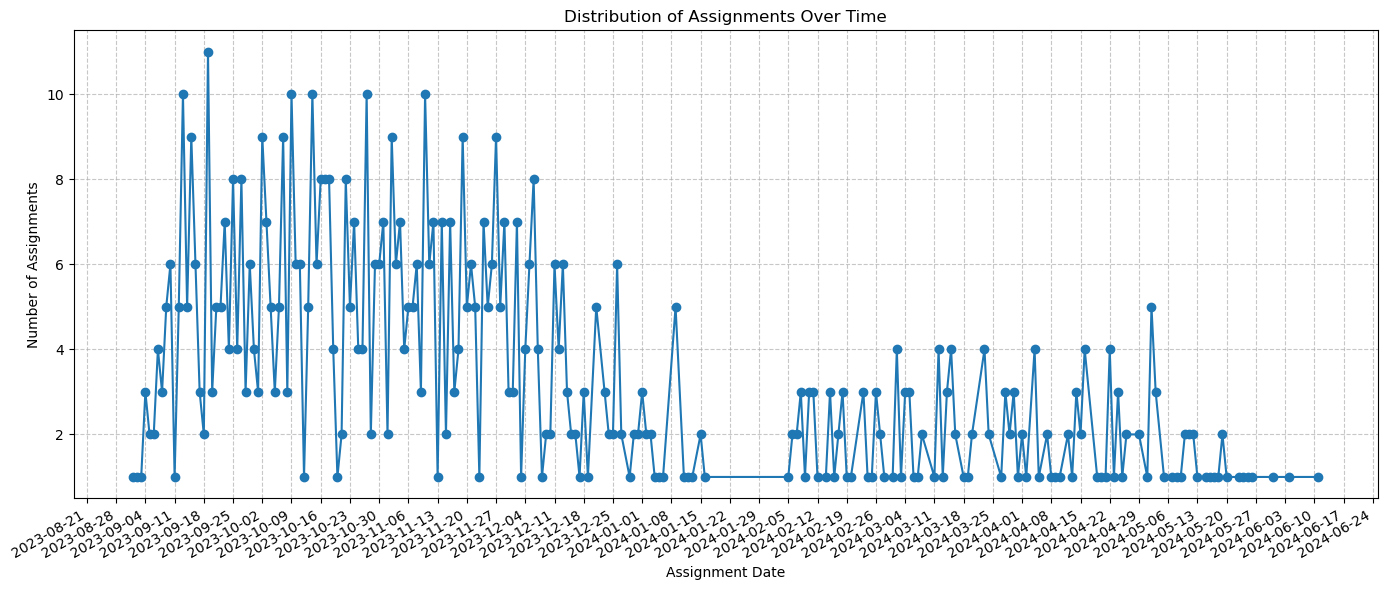

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Assuming all_assignments is your DataFrame with an 'assignDate' column

# Convert 'assignDate' to datetime if it's not already
all_assignments['assignDate'] = pd.to_datetime(all_assignments['assignDate'])

# Sort by date
all_assignments_sorted = all_assignments.sort_values('assignDate')

# Count assignments per date
assignments_by_date = all_assignments.groupby('assignDate').size().reset_index(name='count')

# Plot
plt.figure(figsize=(14, 6))
plt.plot(assignments_by_date['assignDate'], assignments_by_date['count'], marker='o')

# Format the x-axis to show dates clearly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))  # Show tick every 7 days
plt.gcf().autofmt_xdate()  # Rotate date labels

# Add labels and title
plt.xlabel('Assignment Date')
plt.ylabel('Number of Assignments')
plt.title('Distribution of Assignments Over Time')
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

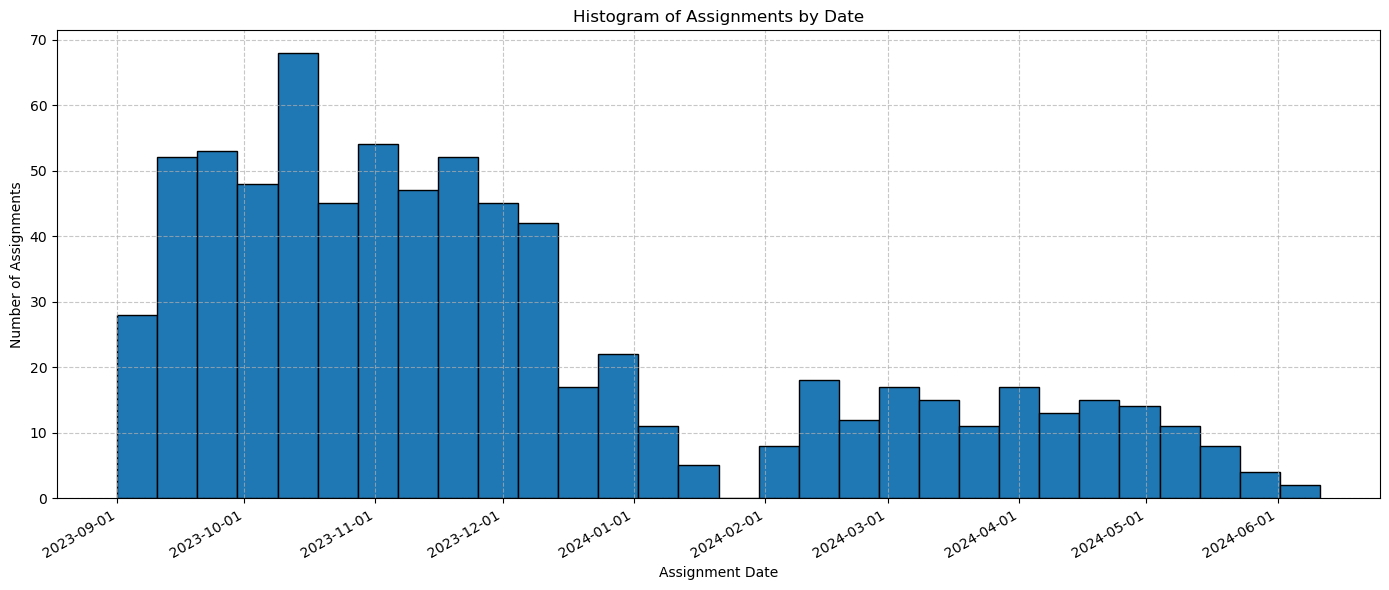

In [7]:
plt.figure(figsize=(14, 6))
plt.hist(all_assignments['assignDate'], bins=30, edgecolor='black')
plt.xlabel('Assignment Date')
plt.ylabel('Number of Assignments')
plt.title('Histogram of Assignments by Date')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
all_students = all_students[all_students['parsed_courses'].apply(len) > 0]
all_students

,courses,createdAt,email,entryYear,gradeLevel,id,name,phone,schoolId,totalScore,type,updatedAt,parsed_courses
0,"[""CRS960285"", ""CRS262471"", ""CRS622832"", ""CRS69...",2025-05-19T20:15:13.607124,timothy861@student.revoducate.edu,2023,9,406896307,Timothy Chambers,815-646-0462x575,SCH920609,64.4,student,2025-05-19T20:15:13.637618,"[CRS960285, CRS262471, CRS622832, CRS698669, C..."
1,"[""CRS960285"", ""CRS262471"", ""CRS622832"", ""CRS69...",2025-05-19T20:15:13.608122,andres673@student.revoducate.edu,2020,12,189073804,Andres Cook,001-791-495-1117x770,SCH920609,75.1,student,2025-05-19T20:15:13.638618,"[CRS960285, CRS262471, CRS622832, CRS698669, C..."
2,"[""CRS960285"", ""CRS262471"", ""CRS622832"", ""CRS69...",2025-05-19T20:15:13.607124,christopher150@student.revoducate.edu,2023,9,268953945,Christopher Velazquez,489-222-7378,SCH920609,80.3,student,2025-05-19T20:15:13.639790,"[CRS960285, CRS262471, CRS622832, CRS698669, C..."
3,"[""CRS960285"", ""CRS262471"", ""CRS698669"", ""CRS45...",2025-05-19T20:15:13.608122,cynthia164@student.revoducate.edu,2021,11,540321422,Cynthia Tyler,001-879-788-4080x9376,SCH920609,98.8,student,2025-05-19T20:15:13.641565,"[CRS960285, CRS262471, CRS698669, CRS453759]"
4,"[""CRS960285"", ""CRS262471"", ""CRS622832"", ""CRS69...",2025-05-19T20:15:13.607124,jennifer169@student.revoducate.edu,2023,9,772372806,Jennifer Jordan,001-778-522-6441x3951,SCH920609,59.9,student,2025-05-19T20:15:13.642566,"[CRS960285, CRS262471, CRS622832, CRS698669, C..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,"[""CRS649333"", ""CRS658954"", ""CRS466909"", ""CRS04...",2025-05-19T20:15:13.619782,kevin644@student.pardeshannaagriculturalorgani...,2020,12,117264249,Kevin Pennington,(455)423-2368,SCH816564,88.7,student,2025-05-19T20:15:14.400534,"[CRS649333, CRS658954, CRS466909, CRS040511, C..."
146,"[""CRS649333"", ""CRS658954"", ""CRS466909"", ""CRS04...",2025-05-19T20:15:13.619782,morgan671@student.pardeshannaagriculturalorgan...,2023,9,224425792,Morgan Whitaker,307.950.1287,SCH816564,76.4,student,2025-05-19T20:15:14.417972,"[CRS649333, CRS658954, CRS466909, CRS040511, C..."
147,"[""CRS649333"", ""CRS658954"", ""CRS466909"", ""CRS85...",2025-05-19T20:15:13.619782,kathy809@student.pardeshannaagriculturalorgani...,2020,12,184046103,Kathy Turner,316-571-8289,SCH816564,57.0,student,2025-05-19T20:15:14.432578,"[CRS649333, CRS658954, CRS466909, CRS853885, C..."
148,"[""CRS649333"", ""CRS658954"", ""CRS466909"", ""CRS04...",2025-05-19T20:15:13.619782,alejandro680@student.pardeshannaagriculturalor...,2023,9,660001614,Alejandro Johnson,617-526-7983x7787,SCH816564,67.1,student,2025-05-19T20:15:14.442391,"[CRS649333, CRS658954, CRS466909, CRS040511, C..."


In [9]:
##students by grade
students_by_grade = all_students['totalScore'].value_counts().reset_index()
students_by_grade.columns = ['Grade', 'Student Count']
students_by_grade = students_by_grade.sort_values('Grade')
students_by_grade.to_csv('students_by_grade.csv', index=False)

In [10]:
studentwithzero = all_students[all_students['totalScore'] == 0]
studentwithzero

,courses,createdAt,email,entryYear,gradeLevel,id,name,phone,schoolId,totalScore,type,updatedAt,parsed_courses


In [11]:
all_students = pd.read_csv('students.csv')

In [12]:
student_assignments = pd.read_csv('studentAssignments.csv')
student_assignments.head()

,assessmentScore,assignmentId,courseId,createdAt,id,isLate,moduleId,studentId,submissionDate,timeSpentMinutes,updatedAt
0,75.7,ASG836665,CRS960285,2025-05-19T20:15:13.636619,sa_2af29cb4,False,MOD501641,406896307,2023-09-07T00:00:00,108,2025-05-19T20:15:13.636619
1,83.3,ASG003266,CRS960285,2025-05-19T20:15:13.636619,sa_12bd6742,False,MOD843829,406896307,2023-09-14T00:00:00,370,2025-05-19T20:15:13.636619
2,64.4,ASG636941,CRS960285,2025-05-19T20:15:13.636619,sa_0ff1af0e,True,MOD843829,406896307,2023-09-25T00:00:00,111,2025-05-19T20:15:13.636619
3,62.8,ASG654569,CRS960285,2025-05-19T20:15:13.636619,sa_177c371f,False,MOD429230,406896307,2023-09-25T00:00:00,58,2025-05-19T20:15:13.636619
4,78.7,ASG570334,CRS960285,2025-05-19T20:15:13.636619,sa_4bc33a1b,False,MOD390792,406896307,2023-10-01T00:00:00,70,2025-05-19T20:15:13.636619


In [13]:
## find student by id in student_assignments
student_id = 380215769
student_assignments[student_assignments['studentId'] == student_id]


,assessmentScore,assignmentId,courseId,createdAt,id,isLate,moduleId,studentId,submissionDate,timeSpentMinutes,updatedAt


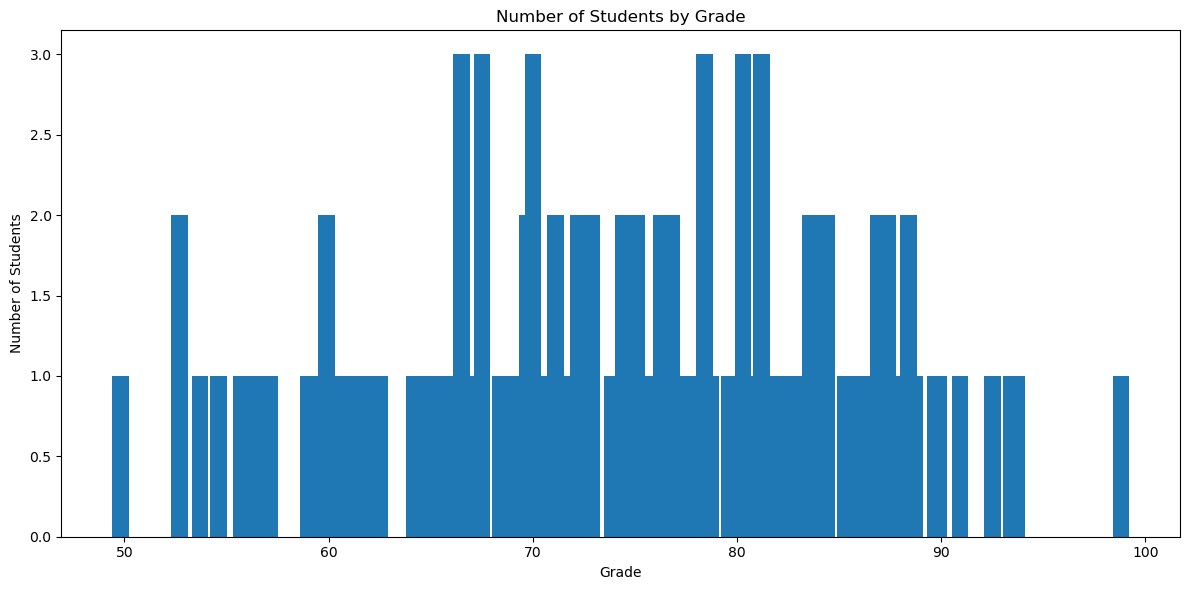

In [14]:
##plotting students by grade
plt.figure(figsize=(12, 6))
plt.bar(students_by_grade['Grade'], students_by_grade['Student Count'])
plt.xlabel('Grade')
plt.ylabel('Number of Students')

plt.title('Number of Students by Grade')
plt.tight_layout()
plt.show()


In [15]:
import pandas as pd
assignments = pd.read_csv('assignments.csv')
courses = pd.read_csv('courses.csv')
modules = pd.read_csv('modules.csv')
student_assignments = pd.read_csv('studentAssignments.csv')
student_courses = pd.read_csv('studentCourses.csv')
student = pd.read_csv('students.csv')
teachers = pd.read_csv('teachers.csv')
schools = pd.read_csv('schools.csv')
## name of table and columns 

table_names = {
    'assignments': assignments.columns.tolist(),
    'courses': courses.columns.tolist(),
    'modules': modules.columns.tolist(),
    'student_assignments': student_assignments.columns.tolist(),
    'student_courses': student_courses.columns.tolist(),
    'student': student.columns.tolist(),
    'teachers': teachers.columns.tolist(),
    'schools': schools.columns.tolist()
}
table_names
# save to txt file
with open('table_names.txt', 'w') as f:
    for table, columns in table_names.items():
        f.write(f"{table}:\n")
        f.write(", ".join(columns) + "\n\n")
        

In [16]:
import pandas as pd
import numpy as np

# Assuming students_df is your DataFrame

# Convert the 'courses' column to actual lists if they are strings
all_students['courses'] = all_students['courses'].apply(lambda x: eval(x) if isinstance(x, str) else x)

# Filter out rows with empty lists in the 'courses' column
students_df = all_students[all_students['courses'].apply(lambda x: len(x) > 0)]

# Reset the index if needed
students_df = students_df.reset_index(drop=True)

# Display the cleaned DataFrame
print(students_df)

                                               courses  \
0    [CRS960285, CRS262471, CRS622832, CRS698669, C...   
1    [CRS960285, CRS262471, CRS622832, CRS698669, C...   
2    [CRS960285, CRS262471, CRS622832, CRS698669, C...   
3         [CRS960285, CRS262471, CRS698669, CRS453759]   
4    [CRS960285, CRS262471, CRS622832, CRS698669, C...   
..                                                 ...   
145  [CRS649333, CRS658954, CRS466909, CRS040511, C...   
146  [CRS649333, CRS658954, CRS466909, CRS040511, C...   
147  [CRS649333, CRS658954, CRS466909, CRS853885, C...   
148  [CRS649333, CRS658954, CRS466909, CRS040511, C...   
149  [CRS649333, CRS658954, CRS466909, CRS040511, C...   

                      createdAt  \
0    2025-05-19T20:15:13.607124   
1    2025-05-19T20:15:13.608122   
2    2025-05-19T20:15:13.607124   
3    2025-05-19T20:15:13.608122   
4    2025-05-19T20:15:13.607124   
..                          ...   
145  2025-05-19T20:15:13.619782   
146  2025-05-19T20:15:1

In [17]:
# Count the number of students by entry year
students_by_entry_year = students_df['entryYear'].value_counts().reset_index()
students_by_entry_year.columns = ['Entry Year', 'Student Count']
students_by_entry_year = students_by_entry_year.sort_values('Entry Year')

# Display the data
print(students_by_entry_year)

# Save to a CSV file
students_by_entry_year.to_csv('students_by_entry_year.csv', index=False)

   Entry Year  Student Count
0        2020             47
2        2021             36
3        2022             31
1        2023             36


In [18]:
all_students.head()

,courses,createdAt,email,entryYear,gradeLevel,id,name,phone,schoolId,totalScore,type,updatedAt
0,"[CRS960285, CRS262471, CRS622832, CRS698669, C...",2025-05-19T20:15:13.607124,timothy861@student.revoducate.edu,2023,9,406896307,Timothy Chambers,815-646-0462x575,SCH920609,64.4,student,2025-05-19T20:15:13.637618
1,"[CRS960285, CRS262471, CRS622832, CRS698669, C...",2025-05-19T20:15:13.608122,andres673@student.revoducate.edu,2020,12,189073804,Andres Cook,001-791-495-1117x770,SCH920609,75.1,student,2025-05-19T20:15:13.638618
2,"[CRS960285, CRS262471, CRS622832, CRS698669, C...",2025-05-19T20:15:13.607124,christopher150@student.revoducate.edu,2023,9,268953945,Christopher Velazquez,489-222-7378,SCH920609,80.3,student,2025-05-19T20:15:13.639790
3,"[CRS960285, CRS262471, CRS698669, CRS453759]",2025-05-19T20:15:13.608122,cynthia164@student.revoducate.edu,2021,11,540321422,Cynthia Tyler,001-879-788-4080x9376,SCH920609,98.8,student,2025-05-19T20:15:13.641565
4,"[CRS960285, CRS262471, CRS622832, CRS698669, C...",2025-05-19T20:15:13.607124,jennifer169@student.revoducate.edu,2023,9,772372806,Jennifer Jordan,001-778-522-6441x3951,SCH920609,59.9,student,2025-05-19T20:15:13.642566
